# Predicting Movie Revenue From Movie Budget

**Authors:** Audrey Vo, Roxanna Ng, Nikita Prabhu, Philip Chen

## Summary

This study investigates how movie budget predicts domestic box office revenue using the Bechdel Test movie dataset from FiveThirtyEight. Exploratory anaylsis revealed right-skewed distributions for both budget and revenue, which were log-transformed to stabilize variance. A linear regression model and a K-nearest neighbours (KNN) regression model were fitted to predict log-transformed domestic revenue from log-transformed movie budget. Both models showed moderate predictive performance, with a root mean squared prediction error (RMSPE) of roughly 1.27 and 1.28 log units, respectively. The results suggest that while higher budgets are generally associated with higher revenue, budget alone cannot fully explain the variability in box office performance. These findings highlight the complexity of film revenue prediction and the importance of incorporating additional factors beyond production budget.

## Introduction

The financial performance of a film is often assumed to be strongly related to its production budget. Higher budgets allow studios to invest in elements such as well-known actors, special effects, marketing campaigns, and larger production teams, which are often assumed to influence audience appeal and box office revenu (Baasuroy, Chatterjee, & Ravid, 2003). However, the extent to which movie budgets actually predict revenue remains uncertain, as many lower-budget films have seen significant success in the box office while some high-budget productions fail to recover the costs associated with making the movie (De Vany & Walls, 1999).

Understanding the relationship between production budget and revenue can provide insight into whether increased financial investments reliably leads to higher financial returns. In this analysis, we use FiveThirtyEight's Bechdel Test dataset, which contains descriptive information, production budgets and domestic box office revenue of 1,615 films released between 1990 and 2013 to answer the question: **How does movie budget predict movie revenue?** (FiveThirtyEight, 2014).

### Research Question

How does movie budget predict movie revenue? 

### The Data Set

In [3]:
library(fivethirtyeight)
library(dplyr)
library(ggplot2)
library(tidymodels)

### Loading in Data

In [4]:
data("bechdel", package = "fivethirtyeight")
write.csv(bechdel, "data/raw/raw_bechdel.csv", row.names = FALSE)

Warning message in file(file, ifelse(append, "a", "w")):
"cannot open file 'data/raw/raw_bechdel.csv': No such file or directory"


ERROR: Error in file(file, ifelse(append, "a", "w")): cannot open the connection


### Cleaning Data

Since our research question only requires studying 2 variables (movie budget - "budget", movie revenue - "domgross"), we will filter the data to only observe those 2 columns during our analysis. 

In [ ]:
movie_data <- bechdel[, c("budget", "domgross")]
head(movie_data)

budget,domgross
<int>,<dbl>
13000000,25682380
45000000,13414714
20000000,53107035
61000000,75612460
40000000,95020213
225000000,38362475


**Table 1 :** First 6 rows of the data

Next, we will check our data for any null values and filter them out if there are any. 

In [ ]:
print(paste("# of null values (before filtering):", sum(is.na(movie_data))))

movie_data <- movie_data %>%
  filter(!is.na(budget), !is.na(domgross))

print(paste("# of null values (after filtering):", sum(is.na(movie_data))))

[1] "# of null values (before filtering): 17"
[1] "# of null values (after filtering): 0"


We will also check for any budget/revenue with a value of 0, since any movie with a $0 budget/revenue is most likely missing data.

In [ ]:
print(sum(movie_data$budget == 0))
print(sum(movie_data$domgross == 0))

[1] 0
[1] 1


After seeing there is one entry with a non-zero budget but $0 revenue, we will first check to see what this value looks like. Since the value has a very high budget, we will say this entry is most likely having its appropriate budget missing and filter it out of the data set. 

In [ ]:
movie_data[movie_data$domgross == 0, ]

movie_data <- movie_data %>%
  filter(budget > 0, domgross > 0)

budget,domgross
<int>,<dbl>
18000000,0


**Table 2 :** Movies with a $0 revenue.

In [ ]:
print(sum(movie_data$budget == 0))
print(sum(movie_data$domgross == 0))

[1] 0
[1] 0


## EDA

Here, we will look at some general summary statistics of our data: 

In [ ]:
summary(movie_data)

     budget             domgross        
 Min.   :     7000   Min.   :      828  
 1st Qu.: 12000000   1st Qu.: 16320870  
 Median : 30000000   Median : 42239614  
 Mean   : 45174408   Mean   : 69170974  
 3rd Qu.: 60000000   3rd Qu.: 93382814  
 Max.   :425000000   Max.   :760507625  

Here, we will look at the general shape/values in our data:

In [ ]:
str(movie_data)

tibble [1,776 × 2] (S3: tbl_df/tbl/data.frame)
 $ budget  : int [1:1776] 13000000 45000000 20000000 61000000 40000000 225000000 92000000 12000000 13000000 130000000 ...
 $ domgross: num [1:1776] 25682380 13414714 53107035 75612460 95020213 ...


Next, we will use different plots to examine the skew/behaviour of budget and revenue in the data. 

In the box plots, we can see there is a heavy right skew in both variables, seeing as most of the movies are clustered at the bottom with only few movies pulling the tail towards higher values.

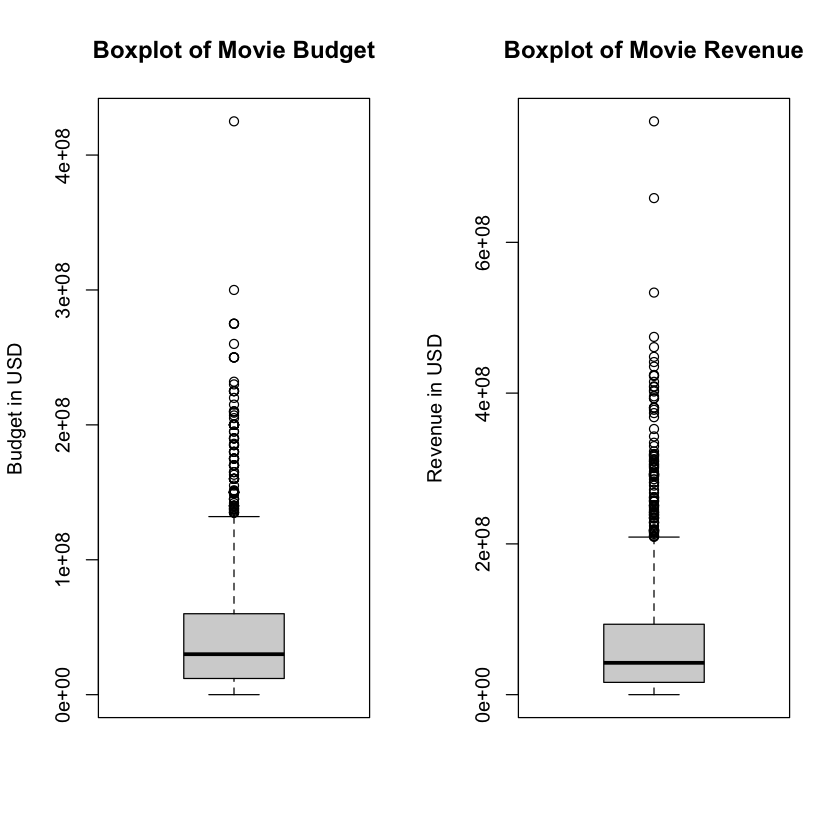

In [ ]:
par(mfrow = c(1, 2))
boxplot(movie_data$budget, main = "Boxplot of Movie Budget", ylab = "Budget in USD")
boxplot(movie_data$domgross, main = "Boxplot of Movie Revenue", ylab = "Revenue in USD")
par(mfrow = c(1,1))

**Figure 1(left):** Boxplot of movie budget \
**Figure 1(right):** Boxplot of movie revenue


In the histograms, we can once again observe how both variance are heavily right skewed, and like in the box plots above, we see only some movies with higher values which indicates we have some outliers in our data. In addition, after seeing both the box plot and histogram, we observe that the values have a very wide range and spread.

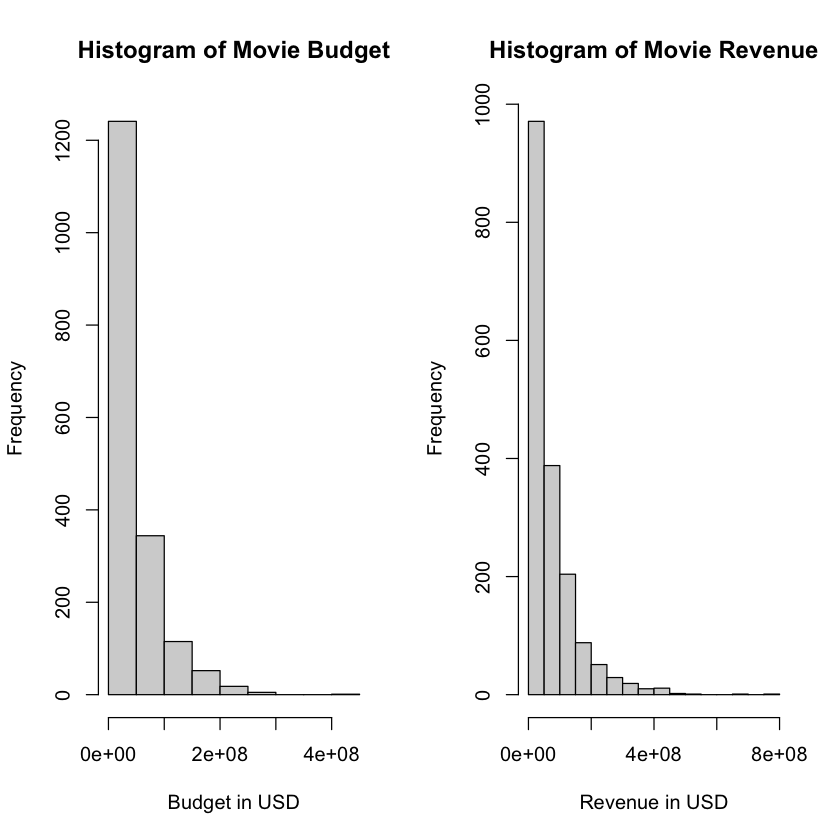

In [ ]:
par(mfrow = c(1, 2))
hist(movie_data$budget, main = "Histogram of Movie Budget", xlab = "Budget in USD")
hist(movie_data$domgross, main = "Histogram of Movie Revenue", xlab = "Revenue in USD")
par(mfrow = c(1,1))

**Figure 2(left):** Histogram of movie budget \
**Figure 2(left):** Histogram of movie revenue

Next, we will look at the behaviour of movie budget with movie revenue on the untransformed data to help us gather an idea of how linear the relationship may be. From observing the scatter plot, we can see that the data may have a positive linear relationship.  The spread of the values are also very wide, making it difficult to conclude how strong this linear relationship may be.

`geom_smooth()` using formula = 'y ~ x'


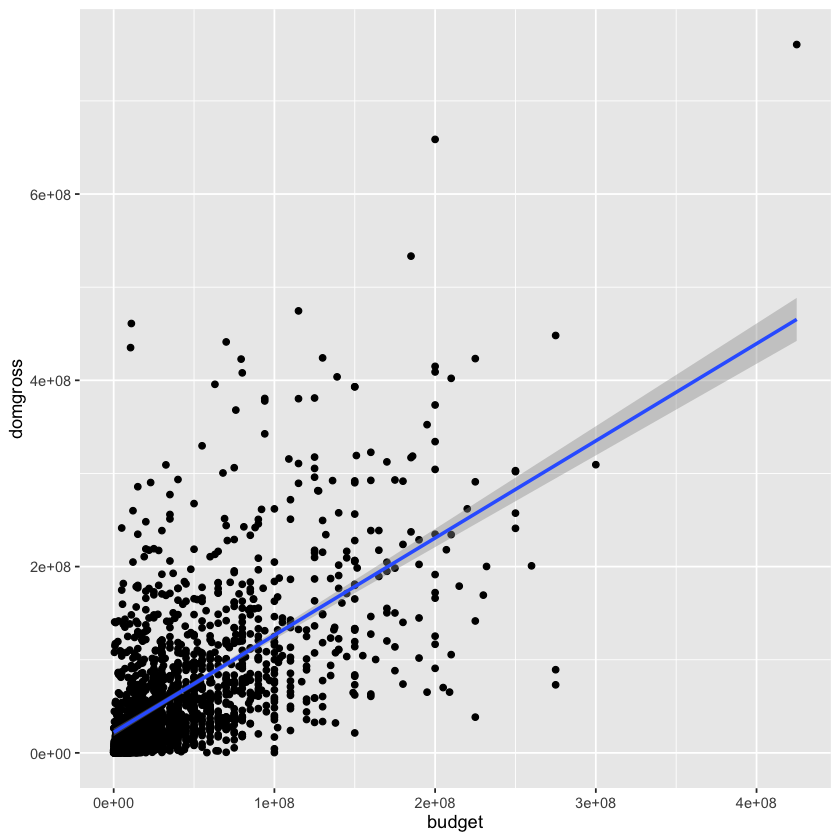

In [ ]:
budget_rev_plot <- ggplot(movie_data, aes(x = budget, y = domgross)) +
  geom_point() +
  geom_smooth(method = "lm")
budget_rev_plot

**Figure 3 :** Scatterplot of Domestic Revenue vs Movie Budget

Since just observing the scatter plot makes it difficult to conclude how linear our data is, we can observe the correlation between movie budget and revenue. We can see that we have a correlation of around 0.627, indicating that there may be a moderate positive relationship between our two variables. This correlation value allows us to further our analysis to see how well movie budget may predict movie revenue. 

In [ ]:
cor(movie_data$budget, movie_data$domgross)

[1] 0.6268848

Previously, we observed a very large spread. To account for this, we will apply a variance stabilizing function (log) to our variables to help stabilize the wide range of values. We can see in the new scatter plot that applying this function helps make the data less spread out and easier to observe for patterns. 

`geom_smooth()` using formula = 'y ~ x'


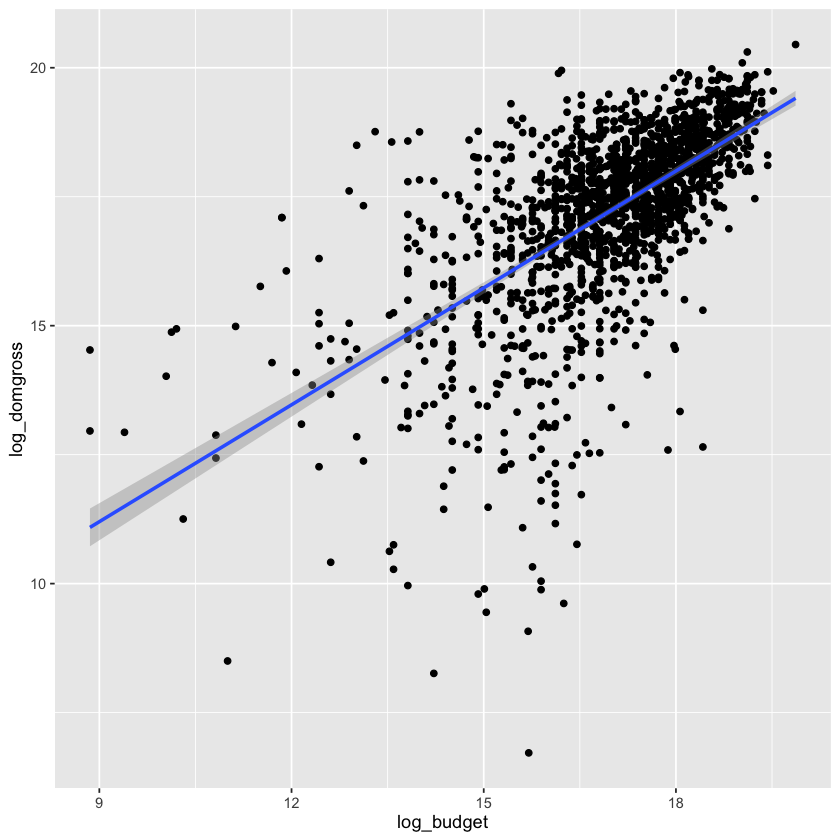

In [ ]:
movie_data <- movie_data %>% 
  mutate(log_budget = log(budget), log_domgross = log(domgross))

log_budget_rev_plot <- ggplot(movie_data, aes(x = log_budget, y = log_domgross)) +
  geom_point() +
  geom_smooth(method = "lm")
log_budget_rev_plot

**Figure 4 :** Scatterplot of log(Domestic Revenue) vs log(Movie Budget

Here is our data with the log-transformed budget and revenue added:

In [ ]:
head(movie_data)
write.csv(movie_data, "data/processed/clean_bechdel.csv", row.names = FALSE)

budget,domgross,log_budget,log_domgross
<int>,<dbl>,<dbl>,<dbl>
13000000,25682380,16.38046,17.06132
45000000,13414714,17.62217,16.41186
20000000,53107035,16.81124,17.78782
61000000,75612460,17.92638,18.14113
40000000,95020213,17.50439,18.36960
225000000,38362475,19.23161,17.46259


**Table 3 :** First six rows with budget, domestic gross, and their log-transformed values

## Methods and Results

Due to the relationship between movie budget and movie revenue being relatively linear, we will use a linear regression for analysis. Below, we split the data and summarize the number of observations in each training and test split. We also look at the mean values for the log-transformed budget and revenue columns in each training and test split. 

In [ ]:
set.seed(120)
data_split <- initial_split(movie_data, prop = 0.7)
train <- training(data_split)
test <- testing(data_split) 

train_n <- train |> summarize(n = n()) |> pull()
print(paste("Training data row count: ", train_n))
test_n <- test |> summarize(n = n()) |> pull()
print(paste("Test data row count: ", test_n))

train_mean <- train |> summarize(train_log_budget_mean = mean(log_budget),
                                 train_log_domgross_mean = mean(log_domgross))
train_mean
test_mean <- test |> summarize(test_log_budget_mean = mean(log_budget),
                                 test_log_domgross_mean = mean(log_domgross))
test_mean

[1] "Training data row count:  1243"
[1] "Test data row count:  533"


train_log_budget_mean,train_log_domgross_mean
<dbl>,<dbl>
16.98953,17.24123


test_log_budget_mean,test_log_domgross_mean
<dbl>,<dbl>
16.9104,17.16077


**Table 4 (top):** Mean log-budget and log-domestic revenue for the training set \
**Table 5 (bottom):** Mean log-budget and log-domestic revenue for the test set

Below we fit a simple linear regression with the log-transformed versions of movie budget and movie revenue to account for data skew. The predictor (log-transformed movie budget) is statistically significant. 

In [ ]:
lm <- lm(formula = log_domgross ~ log_budget, data = train)
summary(lm)


Call:
lm(formula = log_domgross ~ log_budget, data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-9.5448 -0.5775  0.1807  0.7754  4.3182 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.33845    0.48805   8.889   <2e-16 ***
log_budget   0.75945    0.02863  26.524   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.391 on 1241 degrees of freedom
Multiple R-squared:  0.3618,	Adjusted R-squared:  0.3613 
F-statistic: 703.5 on 1 and 1241 DF,  p-value: < 2.2e-16


Using the fitted model above, we predict on the test set. 

In [ ]:
preds <- predict(lm, test) |> bind_cols(test) 
preds <- preds |> rename(log_domgross_preds = ...1) |> select(log_domgross_preds, log_budget, log_domgross)
head(preds)

New names:
• `` -> `...1`


log_domgross_preds,log_budget,log_domgross
<dbl>,<dbl>,<dbl>
17.72169,17.62217,16.41186
17.27529,17.03439,17.43463
17.41376,17.21671,17.37845
18.40050,18.51599,17.93840
16.98240,16.64872,17.80893
16.05300,15.42495,18.24139


**Table 6 :** Predicted log domestic revenue with the corresponding log-budget and actual log-domestic revenue for test set

`geom_smooth()` using formula = 'y ~ x'


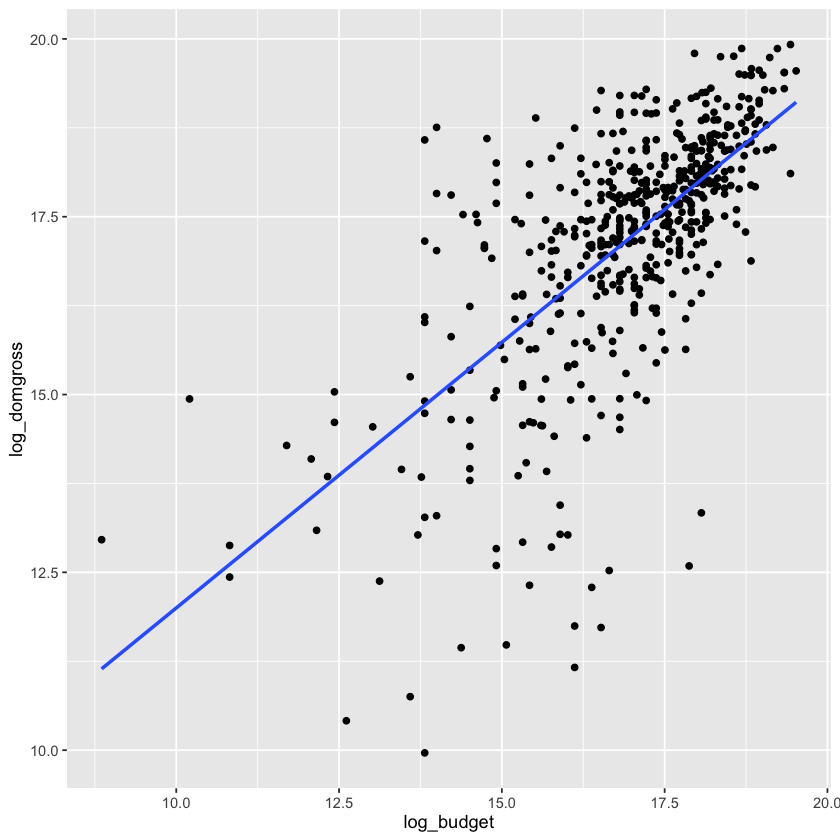

In [ ]:
preds_plot <- preds |>
    ggplot(aes(x = log_budget, y = log_domgross)) +
    geom_point() +
    geom_smooth(method = "lm", se = FALSE)
preds_plot

**Figure 5 :** Scatterplot of log(movie budget) vs log(domestic revenue) for the test set

In [ ]:
metrics <- metrics(preds, truth = log_domgross, estimate = log_domgross_preds)|>
filter(.metric=='rmse')
metrics

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1.266987


**Table 7 :** RMSPE of the linear regression model

In [ ]:
exp(metrics$.estimate)

[1] 3.550138

The RMSPE is 1.267. This means on average, the model’s predicted log revenue differs from the actual log revenue by about 1.267. On average, the predicted revenue can be roughly 3.5 times higher or lower than the actual revenue.

### K-Nearest Neighbours Regression model

Below, we also try fitting a K-nearest neighbours (KNN) regression model using cross-validation to compare whether RMSPE might be improved compared to the linear model. First, we create the recipe and set log-transformed revenue as our dependent variable and log-transformed budget as our independent predictor variable, while scaling and centering the predictor. 

Next, we set our model parameters to use KNN for regression, split the data into 5 folds for cross validation, and create a workflow with our model and recipe.

In [ ]:
knn_recipe <- recipe(log_domgross ~ log_budget, data = train) |>
  step_scale(all_predictors()) |>
  step_center(all_predictors())

knn_spec <- nearest_neighbor(weight_func = "rectangular",
                              neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("regression")

knn_vfold <- vfold_cv(train, v = 10, strata = log_domgross)

knn_wkflw <- workflow() |>
  add_recipe(knn_recipe) |>
  add_model(knn_spec)

Below we test every 3rd number of neighbours between 1 and 200, set using tibble(), then filtered for the metric root mean standard error (RMSE) to evaluate the fit. 

In [ ]:
set.seed(120)
gridvals <- tibble(neighbors = seq(from = 1, to = 200, by = 3))

knn_results <- knn_wkflw |>
  tune_grid(resamples = knn_vfold, grid = gridvals) |>
  collect_metrics() |>
  filter(.metric == "rmse")

head(knn_results)

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,rmse,standard,1.768727,10,0.07345088,pre0_mod01_post0
4,rmse,standard,1.506490,10,0.07384989,pre0_mod02_post0
7,rmse,standard,1.434970,10,0.07054968,pre0_mod03_post0
10,rmse,standard,1.400989,10,0.06422357,pre0_mod04_post0
13,rmse,standard,1.377193,10,0.06266466,pre0_mod05_post0
16,rmse,standard,1.377975,10,0.06207412,pre0_mod06_post0


**Table 7 :** Cross-validated RMSE for different K values in KNN regression (first 6 rows).

Below, we filter the results to get the K value with the lowest associated RMSE.

In [ ]:
knn_min <- knn_results |>
  filter(mean == min(mean))

knn_min

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
88,rmse,standard,1.360276,10,0.06144779,pre0_mod30_post0


**Table 8 :** The minimum RMSE is at K=88.

In [ ]:
set.seed(120)
kmin <- knn_min |> pull(neighbors)

knn_spec_min <- nearest_neighbor(weight_func = "rectangular", neighbors = kmin) |>
  set_engine("kknn") |>
  set_mode("regression")

cv_metrics <- workflow() |>
  add_recipe(knn_recipe) |>
  add_model(knn_spec_min) |>
   fit_resamples(resamples = knn_vfold)|>
   collect_metrics() |>
   filter(.metric == 'rmse')
cv_metrics

.metric,.estimator,mean,n,std_err,.config
<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
rmse,standard,1.360276,10,0.06144779,pre0_mod0_post0


**Table 8 :** Cross-validated RMSE for KNN regression model at K = 88.

For the training set, the average RMSE across the 10 folds is 1.36 log units with a standard error of 0.061.

In [ ]:
knn_fit_min <- workflow() |>
  add_recipe(knn_recipe) |>
  add_model(knn_spec_min) |>
  fit(data = train)

knn_summary <- knn_fit_min |>
  predict(test) |>
  bind_cols(test) |>
  metrics(truth = log_domgross, estimate = .pred) |>
  filter(.metric == 'rmse')

knn_summary

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1.287064


**Table 9 :** RMSPE of the KNN regression model

In [ ]:
exp(knn_summary$.estimate)

[1] 3.622135

The test RMSPE of 1.28 means that, on average, the KNN model’s predicted log revenue differs from the actual log revenue by about 1.28. On average, the predicted revenue can be roughly 3.6 times higher or lower than the actual revenue.

So, both KNN and linear regression have similar predictive accuracy, with linear regression being slightly better.

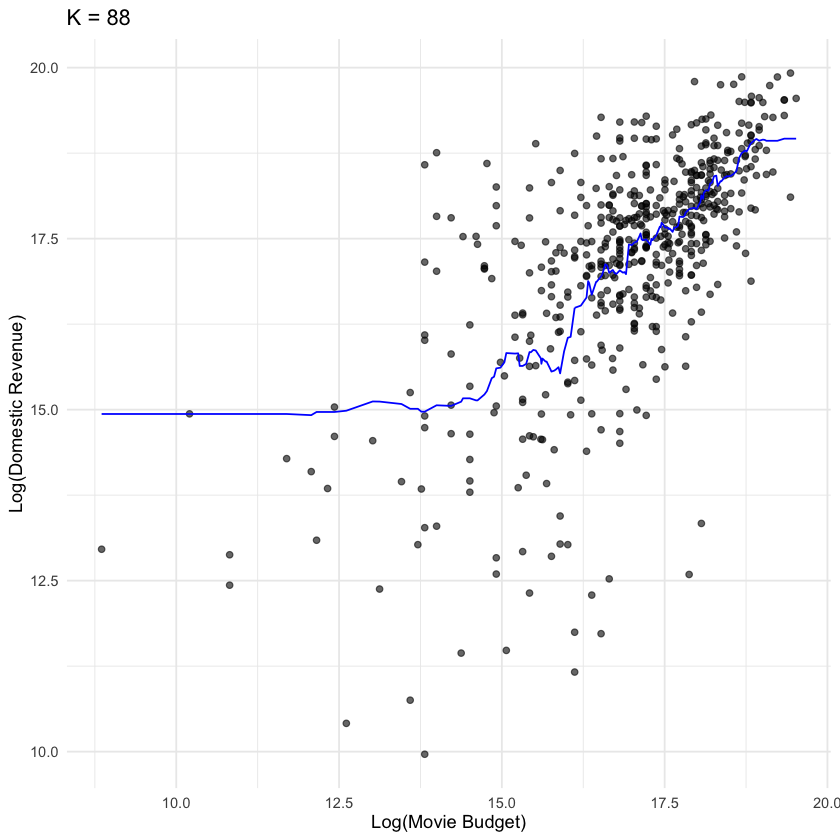

In [ ]:
knn_preds <- knn_fit_min |>
  predict(test) |>
  bind_cols(test) |>
  rename(log_domgross_pred = .pred)

ggplot(knn_preds, aes(x = log_budget, y = log_domgross)) +
  geom_point(alpha = 0.6) +                                
  geom_line(aes(y = log_domgross_pred), color = "blue") +
  labs(
    title = "KNN Regression: Predicted vs Actual",
    x = "Log(Movie Budget)",
    y = "Log(Domestic Revenue)"
  ) + ggtitle(paste0("K = ", kmin)) +
  theme_minimal()

**Figure 6 :** Predicted values of log(movie revenue) (blue line) for the final K-NN regression model

## Discussion

Our analysis suggests that movie budget is moderately associated with domestic box office revenue. The exploratory analysis showed a positive relationship between the two variables, supported by a correlation coefficient of approximately 0.63, indicating a moderate positive association. As the raw data is heavily right-skewed, applying a logarithmic transformation to both variables helped reduce the skewness and produced a more linear relationship suitable for modelling.

The linear regression model fitted on the log-transformed variables indicated that log-budget is a statistically significant predictor of log-revenue. This suggests that increases in movie budget tend to correspond with increases in domestic box office revenue on average. When evaluated on the test set, the model produced an RMSPE of approximately 1.27 log units, meaning predicted revenue may differ from the true revenue by roughly a factor of 3.5 on average. This indicates that budget does provide predictive information, but also highlights that budget alone cannot fully explain the variability in movie revenue.

To evaluate whether a more flexible model could improve prediction accuracy, we also trained a KNN model with cross-validation to tune the number of neighbours. The optimal value with K = 88, producing a test RMSPE of approximately 1.28, very similar to the linear regression model. Since KNN did not significantly improve predictive performance, this suggests that the relationship between log-budget and log-revenue is reasonably captured by the simpler linear model.

Despite the observed relationship, a couple of limitations exist in this analysis. First, the models only consider budget as a single predictor, when movie revenue is likely influenced by many additional factors such as marketing, release timing, critical reception, and star power. Second, the dataset only includes domestic revenue, where particular films may have performed differently internationally.

Future work could improve predictive performance by incorporating additional variables such as genre, production studio, critical reception, and by analyzing worldwide revenue rather than only domestic. More advanced modeling techniques such as random forests or gradient boosting models may also capture nonlinear relationships between features and revenue.

Overall, our findings suggest that **movie budget does have a moderate predictive relationship with domestic revenue**, but it is not a complete predictor of financial success.

## Citations

Basuroy, S., Chatterjee, S., & Ravid, S. A. (2003). *How critical are critical reviews? The box office effects of film critics, star power, and budgets.* Journal of marketing, 67(4), 103-117. https://doi.org/10.1509/jmkg.67.4.103.18692

De Vany, A., & Walls, W. D. (1999). *Uncertainty in the movie industry: Does star power reduce the terror of the box office?* Journal of Cultural Economics, 23(4), 285-318.

FiveThirtyEight. (2014). *Bechdel test movie list*. Retrieved from https://github.com/fivethirtyeight/data/tree/master/bechdel